# ftir_38 — Neutral 1617 cm⁻¹ attribution and mineral-dust sensitivity

## tl;dr

The neutral-baseline 1617 feature remains geographically specific: median spectra peak
inside the 1560–1680 cm⁻¹ window at Addis and Bishoftu, while Delhi and Beijing peak at the
1680 edge (the carbonyl flank). But the 102-filter Addis PMF join gives **no adjusted
association with charcoal fraction (partial r ≈ 0.00, q ≈ 0.98)** and no wood-factor
association. The data therefore support an Ethiopian regional marker, not a specific
charcoal/eucalyptus assignment. For dust, the canonical IMPROVE formula
2.20Al + 2.49Si + 1.63Ca + 2.42Fe + 1.94Ti has the absorption-consistent negative sign,
but significance depends on which locked PLS configuration supplies the residual; the
Addis-winner result is borderline (q ≈ 0.06), whereas potassium remains large and robust.
Mineral dust is a secondary modifier, not the dominant offset explanation.

## Context & Methods

This notebook uses neutral `pspline_arpls` target spectra already materialized by the
calibration explorer, normalized Addis PMF factors, the unified XRF chemistry table, and
locked reconstruction residuals. Both chemistry analyses residualize loading and cyclic
month terms and use 5,000-permutation two-sided tests with within-family BH-FDR.

### Key assumptions

- GF1–GF5 are normalized row-wise before interpretation; raw values are PM2.5 mass
  fractions and do not sum to one.
- PMF GF2 is only a broad wood-burning proxy. It cannot identify eucalyptus.
- The canonical soil formula uses non-negative elemental concentrations in ng m⁻³ and is
  divided by 1000 to yield µg m⁻³.
- `ChemSpec_EC` is excluded as an independent reference because it is circular with HIPS.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, './scripts')
sys.path.insert(0, '../ftir_hips_chem/scripts')
from config import SITES
from plotting import apply_default_style
from theory_test_suite import canonical_soil_tests, neutral_band_and_pmf

apply_default_style()
ROOT = Path('.')
OUT = ROOT / 'output/tables/ftir38'
PLOTS = ROOT / 'output/plots/ftir38'
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

## Data

### Data quality and join coverage

The site table tests peak geometry on each site's median spectrum. The Addis PMF ledger has
102 dated rows, all of which join to an augmented target filter. Chemistry coverage is 188
Addis filters but only 27 Delhi filters, so Delhi dust tests are explicitly low-powered.

In [2]:
site_bands, band_pmf, pmf_tests = neutral_band_and_pmf()
chemistry, dust_tests = canonical_soil_tests()
display(site_bands.round(4))
display(pmf_tests.round(4))
display(chemistry.groupby(['config', 'target'])['IMPROVE_soil_ugm3']
        .agg(['count', 'median']).round(3))

site_bands.to_csv(OUT / 'neutral_band_cross_site_summary.csv', index=False)
band_pmf.to_csv(OUT / 'addis_neutral_band_pmf_join.csv', index=False)
pmf_tests.to_csv(OUT / 'addis_pmf_band_tests.csv', index=False)
chemistry.to_csv(OUT / 'canonical_soil_per_filter.csv', index=False)
dust_tests.to_csv(OUT / 'canonical_soil_residual_tests.csv', index=False)

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


,site,n,median_peak_cm1,median_band_height,median_band_to_CH,median_has_interior_peak,per_filter_interior_peak_pct
0,Addis,253,1616.08,0.0209,1.6277,True,93.2806
1,Bishoftu,26,1619.94,0.0216,1.0480,True,80.7692
2,Delhi,152,1679.08,0.0191,0.7403,False,42.1053
3,Beijing,192,1679.08,0.0161,0.8191,False,42.1875
4,Pasadena,158,1635.37,0.0161,3.8200,True,71.5190


,predictor,n,partial_r,permutation_p,spearman_r,spearman_p,fdr_q
0,sea_salt_frac,102,0.3025,0.0026,0.3901,0.0001,0.0043
1,wood_frac,102,-0.1285,0.1930,-0.0912,0.3622,0.2412
2,charcoal_frac,102,0.0027,0.9754,0.1028,0.3039,0.9754
3,polluted_marine_frac,102,0.3813,0.0004,0.2532,0.0103,0.0010
4,fossil_fuel_frac,102,-0.4564,0.0002,-0.4297,0.0000,0.0010


count  median
config               target                        
addis_winner_k8      addis_augmented    188   4.976
                     indh_augmented      27  11.534
addis_winner_k9      addis_augmented    188   4.976
                     indh_augmented      27  11.534
common_candidate_k20 addis_augmented    188   4.976
                     indh_augmented      27  11.534
delhi_winner_k20     addis_augmented    188   4.976
                     indh_augmented      27  11.534

## Results

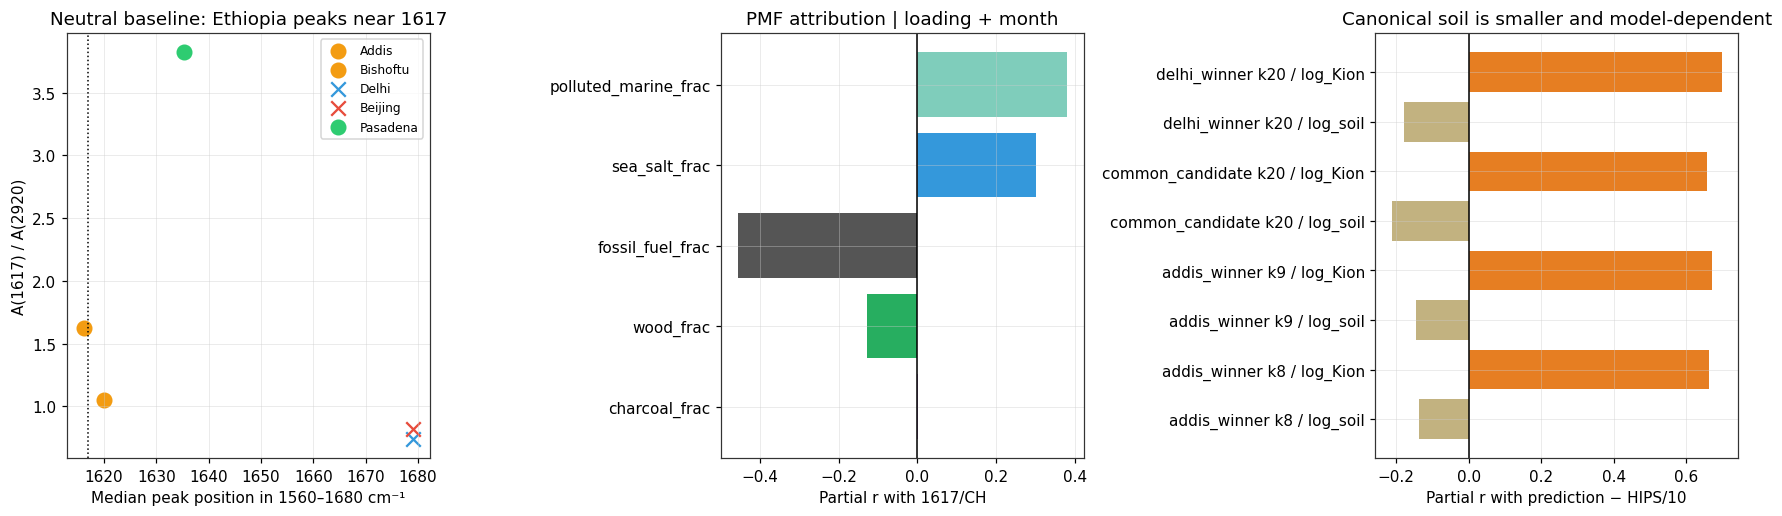

In [3]:
colors = {
    'Addis': SITES['Addis_Ababa']['color'], 'Bishoftu': SITES['Addis_Ababa']['color'],
    'Delhi': SITES['Delhi']['color'], 'Beijing': SITES['Beijing']['color'],
    'Pasadena': SITES['JPL']['color'],
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

for _, row in site_bands.iterrows():
    marker = 'o' if row['median_has_interior_peak'] else 'x'
    axes[0].scatter(row['median_peak_cm1'], row['median_band_to_CH'], s=90,
                    color=colors[row['site']], marker=marker, label=row['site'])
axes[0].axvline(1617, color='black', ls=':', lw=1)
axes[0].set(xlabel='Median peak position in 1560–1680 cm⁻¹',
            ylabel='A(1617) / A(2920)', title='Neutral baseline: Ethiopia peaks near 1617')
axes[0].legend(fontsize=8)

pmf_order = ['charcoal_frac', 'wood_frac', 'fossil_fuel_frac',
             'sea_salt_frac', 'polluted_marine_frac']
pview = pmf_tests.set_index('predictor').loc[pmf_order]
axes[1].barh(pmf_order, pview['partial_r'],
             color=['#8E44AD', '#27AE60', '#555555', '#3498DB', '#7FCDBB'])
axes[1].axvline(0, color='black', lw=1)
axes[1].set(xlabel='Partial r with 1617/CH', title='PMF attribution | loading + month')

focus = dust_tests[
    dust_tests['target'].eq('addis_augmented')
    & dust_tests['predictor'].isin(['log_soil', 'log_Kion'])
].copy()
focus['label'] = focus['config'].str.replace('_k', ' k', regex=False) + ' / ' + focus['predictor']
axes[2].barh(focus['label'], focus['partial_r'],
             color=np.where(focus['predictor'].eq('log_soil'), '#C2B280', '#E67E22'))
axes[2].axvline(0, color='black', lw=1)
axes[2].set(xlabel='Partial r with prediction − HIPS/10',
            title='Canonical soil is smaller and model-dependent')

fig.tight_layout()
fig.savefig(PLOTS / 'neutral_band_pmf_and_soil.png', bbox_inches='tight')
plt.show()

## Takeaways

- **1617 presence is robust; source identity is not.** Addis and Bishoftu retain the
  feature under a neutral baseline, but neither charcoal nor wood PMF fractions predict its
  per-filter strength after loading and season controls.
- **Do not label the band “eucalyptus.”** The available PMF has no eucalyptus-resolved
  factor, and its generic wood factor is null here. Lab burns or source-resolved standards
  are required.
- **Dust has the expected direction but lacks robustness.** Its adjusted effect varies with
  the calibration residual definition and is borderline for the Addis winner; potassium is
  much stronger across configurations.
- **633-nm mineral absorption remains plausible as a modifier**, but these data reject it as
  a sufficient explanation for the large, stable Addis mismatch.